In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv("hmeq.csv")
data

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
BAD        5960 non-null int64
LOAN       5960 non-null int64
MORTDUE    5442 non-null float64
VALUE      5848 non-null float64
REASON     5708 non-null object
JOB        5681 non-null object
YOJ        5445 non-null float64
DEROG      5252 non-null float64
DELINQ     5380 non-null float64
CLAGE      5652 non-null float64
NINQ       5450 non-null float64
CLNO       5738 non-null float64
DEBTINC    4693 non-null float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB



BAD: 1 = müşteri kredi borcunu ödeyemedi ; 0 = kredi geri ödendi

LOAN: Kredi miktarı. Müşterinin aldığı kredinin miktarını ifade eder.

MORTDUE: Mevcut ipotek için ödenmesi gereken tutar

VALUE: Mülk değeri. Müşterinin sahip olduğu mülkün (örneğin bir evin) piyasa değerini temsil eder.

REASON: Kredi alma nedeni. Müşterinin neden kredi başvurusunda bulunduğunu açıklayan kategorik bir değişkendir (örneğin, borç konsolidasyonu, ev tadilatı gibi).

JOB: Meslek. Müşterinin yaptığı işi veya mesleki durumunu gösterir.

YOJ: Mevcut işte geçirilen yıl. Müşterinin şu anki işinde kaç yıldır çalıştığını ifade eder.

DEROG: Kötü kredi olayları. Müşterinin geçmişte yaşadığı ciddi kredi sorunlarını (örneğin iflaslar) gösterir.

DELINQ: Ödenmemiş borç sayısı. Müşterinin kaç adet ödenmemiş borcu olduğunu gösterir.

CLAGE: En eski kredi hesabının yaşı. Müşterinin kredi geçmişindeki en eski hesabın açılma süresini temsil eder.

NINQ: Son 6 ayda yapılan kredi başvuru sayısı. Müşterinin yakın dönemde yaptığı kredi başvurularını gösterir.

CLNO: Toplam kredi hesabı sayısı. Müşterinin sahip olduğu kredi hesaplarının toplam sayısını belirtir.

DEBTINC: Borç/gelir oranı. Müşterinin toplam borçlarının, toplam gelirine oranını temsil eder.



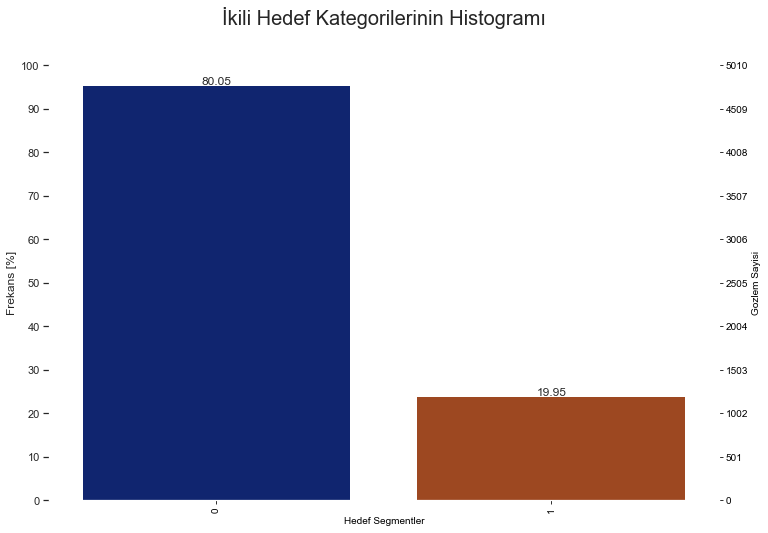

In [5]:
from matplotlib.ticker import FormatStrFormatter  # grafik eksenlerini biçimleme ve işaretleme için. FormatStrFormatter eksenlerdeki değerleri istediğimiz formatta gösterir (%0.2f virgülden sonraki 2 sayı)
import psutil                                     # sistem durumu izleme ve kontrolünü sağlar. İşlemci, hafıza, disk kullanımı, ağ bilgileri ve sistem süreci gibi bilgilere erişim sunar.
import os                                         # işletim sistemi ile etkileşim kurmayı sağlar. Dosya işlemleri, çevre değişkenlerine erişim, süreç yönetimi gibi fonksiyonlar içerir.
import scipy as sp
import matplotlib.ticker as tricker
import seaborn as sns
import matplotlib.pyplot as plt                   # plt eksik, grafikleri göstermek için gerekli

# histogram grafiği için fonksiyon:

def histogram(data, sutun):                    
    gozlem_sayisi = len(data)                  # gözlem sayısı analiz edilecek verinin sayısıdır. yüzdelik hesabı için kullanılacak.
    eksen = sns.countplot(x=sutun, data=data, palette="dark")  # sütun grafiği ile sütunların kategorik dağılımını verir.
    sns.set(font_scale=1)                    # yazı tipi boyutunu ayarlar.
    eksen.set_xlabel('Hedef Segmentler')
    plt.xticks(rotation=90)                    # x ekseni etiketlerini 90 derece döndürür.
    eksen.set_ylabel('Gozlem Sayisi')
    sekil = plt.gcf()
    sekil.set_size_inches(12, 8)               # genişlik 12 inç, yükseklik 8 inç.

    # Ters tarafa da bir dikey eksen (y ekseni) oluşturuluyor, yüzde oranlarını gösterecek.
    eksen2 = eksen.twinx()
    eksen2.yaxis.tick_left()                   # ikinci eksendeki (eksen2) y ekseni etiketlerini sol tarafa
    eksen.yaxis.tick_right()                   # ana eksendeki (eksen) y ekseni etiketlerini sağ tarafa
    eksen2.yaxis.set_label_position('left')    # etiketleri sağ ve sol tarafa yerleştirir.
    eksen.yaxis.set_label_position('right')
    eksen2.set_ylabel('Frekans [%]')

    for p in eksen.patches:                    # grafikteki sütunlar üstüne işlem yapar. Her çubuğun üstüne yüzdelik anotasyon ekler, böylece her kategorinin oranı görülebilir.
        x = p.get_bbox().get_points()[:, 0]    # sütunun sol ve sağ kenarları arasındaki orta noktayı bulmak için kullanılacak
        y = p.get_bbox().get_points()[1, 1]    # sütunun yüksekliği.
        eksen.annotate('{:.2f}'.format(100 * y / gozlem_sayisi), (x.mean(), y), ha='center', va='bottom')  # sütunun üzerine yüzdelik değerleri ekliyor

    # ax nesnesindeki (ana y ekseni) y ekseni için 11 eşit aralıklı çizik (tick) ekler.
    eksen.yaxis.set_major_locator(tricker.LinearLocator(11))
    # İkinci y ekseni olan eksen2 için frekans aralığını %0 ile %100 arasında sınırlıyor. yüzdelik gösterimi için
    eksen2.set_ylim(0, 100)
    eksen2.yaxis.set_major_locator(tricker.MultipleLocator(10))  # 10 birim aralıklarla sıralar. %10, %20 için

    eksen2.grid(None)                          # İkinci eksenin (eksen2) grid çizgilerini kapatır. temiz görüntü için
    plt.title("İkili Hedef Kategorilerinin Histogramı", fontsize=20, y=1.08)
    plt.show()
    # plt.savefig('kolon.png')
    del gozlem_sayisi, x, y                    # gozlem_sayisi, x ve y değişkenlerini bellekten siler.

histogram(data=data, sutun='BAD')                # BAD sütununu analiz ediyoruz. Kaç müşterinin kredi durumunun iyi olduğunu analiz eder. 0 iyi 1 kötü.

BAD sütunu hedef değişkenimizdir. (çıktı)

GRAFİK YORUMU : Bu sonuç, veri setindeki çoğu başvurunun kredi ödemelerini sorunsuz gerçekleştirdiğini gösterir. Ancak, %20 oranında temerrüde düşme durumu bulunması, kredi risk analizinde dikkate alınması gereken bir durumdur.

In [6]:
# İstatistiksel özet
data.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


BAD Sütunu: Ortalama değeri 0.199 yani veri kümesinin %20'si temerrüde düşmüş durumda.

LOAN Sütunu: Ortalama kredi miktarı 18,607, standart sapması ise 12,027. Bu, kredi miktarlarının geniş bir dağılım gösterdiğini ve bazı kredi başvurularının oldukça yüksek olduğunu gösteriyor.

MORTDUE, VALUE, DEBTINC gibi Sütunlar: Emlak ipoteği, emlak değeri, borç-gelir oranı gibi önemli sütunlarda geniş dağılımlar mevcut. Örneğin, VALUE sütununun ortalama değeri 101,776 iken minimum değeri 0, maksimum değeri 1,000,000’dur. Bu da veri kümesinde uç değerlerin olabileceğini gösterir.

In [7]:
# Korelasyonları hesapla
data.corr(method='pearson') 

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
BAD,1.000000,-0.075099,-0.048219,-0.029954,-0.060238,0.276081,0.354107,-0.170499,0.174980,-0.004157,0.199835
LOAN,-0.075099,1.000000,0.228595,0.335393,0.105728,-0.001302,-0.035144,0.088540,0.044487,0.072631,0.084735
MORTDUE,-0.048219,0.228595,1.000000,0.875666,-0.088480,-0.049516,-0.001044,0.140047,0.031392,0.323631,0.154939
VALUE,-0.029954,0.335393,0.875666,1.000000,0.007759,-0.048689,-0.014103,0.171238,-0.004398,0.269149,0.132174
YOJ,-0.060238,0.105728,-0.088480,0.007759,1.000000,-0.065879,0.038153,0.201718,-0.071627,0.024838,-0.055891
DEROG,0.276081,-0.001302,-0.049516,-0.048689,-0.065879,1.000000,0.211832,-0.083047,0.173934,0.061884,0.017065
DELINQ,0.354107,-0.035144,-0.001044,-0.014103,0.038153,0.211832,1.000000,0.022488,0.067812,0.164639,0.052364
CLAGE,-0.170499,0.088540,0.140047,0.171238,0.201718,-0.083047,0.022488,1.000000,-0.116935,0.237987,-0.046477
NINQ,0.174980,0.044487,0.031392,-0.004398,-0.071627,0.173934,0.067812,-0.116935,1.000000,0.088389,0.141344
CLNO,-0.004157,0.072631,0.323631,0.269149,0.024838,0.061884,0.164639,0.237987,0.088389,1.000000,0.185539


BİLGİ : data veri çerçevesindeki sayısal değişkenler arasındaki Pearson korelasyon katsayılarını hesaplar. Sonuç olarak, her değişken çifti arasındaki doğrusal ilişkiyi gösteren bir korelasyon matrisi oluşturulur. Korelasyon değeri +1’e yaklaştıkça pozitif güçlü bir ilişki, -1’e yaklaştıkça negatif güçlü bir ilişki olduğunu gösterir; 0’a yakın değerler ise zayıf ilişkiyi işaret eder.

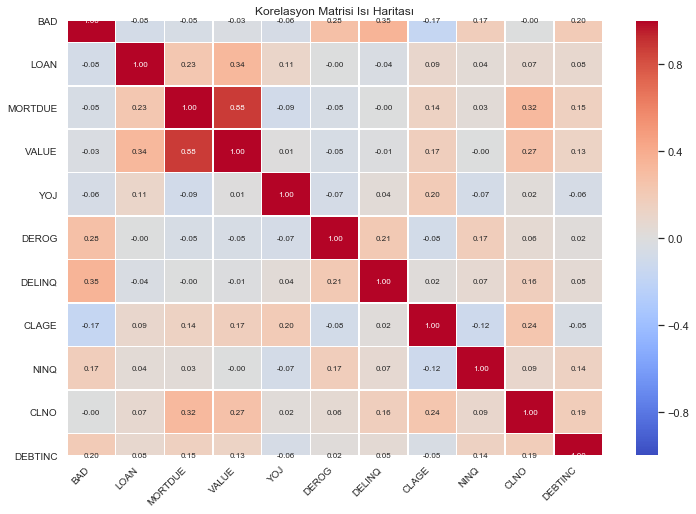

In [9]:
# Korelasyon matrisini oluştur
korelasyon_matrisi = data.corr(method='pearson')

# Isı haritasını çiz
plt.figure(figsize=(12, 8))
sns.heatmap(korelasyon_matrisi, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5, fmt=".2f", annot_kws={"size": 8})
plt.xticks(rotation=45, ha='right', fontsize=10)  # X ekseni etiketlerini döndür ve hizala
plt.yticks(fontsize=10)  # Y ekseni etiket boyutunu ayarla
plt.title("Korelasyon Matrisi Isı Haritası")
plt.show()

BAD ve diğer değişkenler arasındaki korelasyon:

DELINQ (0.354): Kredi geri ödemesini yapamayanlar arasında, ödenmemiş borç sayısı yüksek olanlar daha fazla. Bu yüksek korelasyon, DELINQ'in önemli bir özellik olabileceğini gösteriyor.

DEROG (0.276): Kredi geri ödemesini yapamayanlar arasında, geçmişte kötü kredi olayları yaşamış kişilerle pozitif korelasyon var.

DEBTINC (0.200): Borç/gelir oranı arttıkça kredi geri ödenememe riski de artıyor. Bu, DEBTINC'in önemli bir özellik olabileceğini düşündürüyor.

NINQ (0.175): Son 6 aydaki kredi başvurularının sayısı ile BAD arasında pozitif korelasyon var; daha fazla başvuru yapanların kredi riski daha yüksek.

CLAGE (-0.171): En eski kredi hesabının yaşı arttıkça, BAD değeri düşme eğiliminde, yani kredi geçmişi daha eski olanların kredi ödemelerinde daha başarılı oldukları görülüyor.

Değişkenler arası korelasyonlar:

VALUE ve MORTDUE (0.876): Mülk değeri ve ödenmesi gereken mevcut ipotek tutarı arasında yüksek bir korelasyon var. Bu iki özellik birbirine çok benzer bilgi sunduğu için modelde yalnızca birini kullanmayı düşünebiliriz.

VALUE ve LOAN (0.335): Mülk değeri arttıkça kredi miktarının da artma eğiliminde olduğunu gösteriyor. Ancak bu korelasyon orta seviyede olduğu için her iki değişkenin modelde kalması uygun olabilir.

CLNO ve MORTDUE (0.324): Toplam kredi hesabı sayısı ve ödenmesi gereken ipotek miktarı arasında pozitif bir ilişki var, bu da daha fazla kredi hesabı olanların genelde daha yüksek ipotek borcuna sahip olduklarını gösteriyor.

Önemli değişkenler: DELINQ, DEROG, DEBTINC, NINQ ve CLAGE değişkenlerinin BAD ile anlamlı korelasyonları var; bu değişkenlerin modelde mutlaka yer alması iyi olacaktır.

Yüksek korelasyonlu değişkenler: VALUE ve MORTDUE arasındaki yüksek korelasyon nedeniyle, bilgi tekrarı olmaması için bu iki değişkenden sadece birini kullanmayı düşünebiliriz.

In [13]:
drop_columns=[]
for col in data.columns:
    is_unique = len(data[col].dropna().unique())
    if is_unique == 1:
        drop_columns.append(col)
        
drop_columns

[]

Burada 0 varyans durumuna baktık. DataFrame'imizde 0 varyansa sahip sütun yok.

0 varyans, bir sütundaki tüm değerlerin aynı olduğu anlamına gelir. Yani bu sütunda hiç çeşitlilik yoktur; örneğin, tüm gözlemler aynı değere sahiptir. Bu durum, o değişkenin tüm veri seti boyunca sabit olduğu ve hiçbir değişiklik göstermediği anlamına gelir.

In [10]:
data.isnull().sum()

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

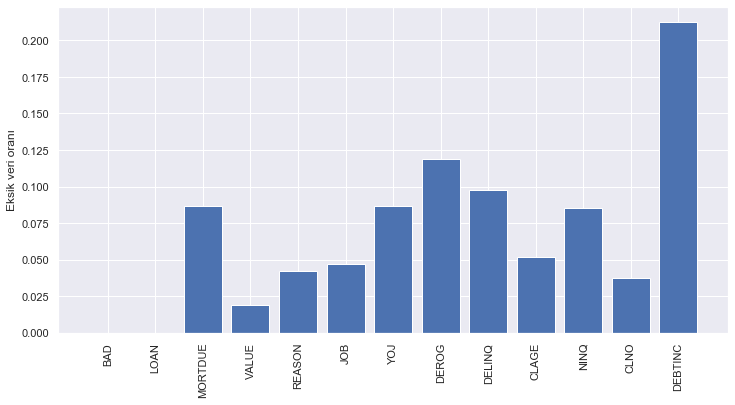

In [11]:
# Eksik değer oranlarını hesaplayın
eksik_sayisi = data.isnull().sum() / len(data)

# Grafik oluşturuluyor
plt.figure(figsize=(12, 6))
plt.xticks(np.arange(len(eksik_sayisi)), eksik_sayisi.index, rotation='vertical')
plt.ylabel('Eksik veri oranı')
plt.bar(np.arange(len(eksik_sayisi)), eksik_sayisi)
plt.show()

In [14]:
for column in data.columns:
    print(f"{column}:\n{data[column].value_counts(normalize=True, dropna=False)}\n")

BAD:
0    0.800503
1    0.199497
Name: BAD, dtype: float64

LOAN:
15000    0.017617
10000    0.013591
20000    0.012416
25000    0.012248
12000    0.011577
           ...   
59700    0.000168
47100    0.000168
79900    0.000168
59500    0.000168
65500    0.000168
Name: LOAN, Length: 540, dtype: float64

MORTDUE:
NaN         0.086913
42000.0     0.001846
47000.0     0.001678
65000.0     0.001510
124000.0    0.001174
              ...   
69612.0     0.000168
76510.0     0.000168
81546.0     0.000168
94672.0     0.000168
72718.0     0.000168
Name: MORTDUE, Length: 5054, dtype: float64

VALUE:
NaN         0.018792
60000.0     0.002517
80000.0     0.002349
85000.0     0.002013
65000.0     0.001846
              ...   
108483.0    0.000168
65054.0     0.000168
84519.0     0.000168
64850.0     0.000168
76207.0     0.000168
Name: VALUE, Length: 5382, dtype: float64

REASON:
DebtCon    0.659060
HomeImp    0.298658
NaN        0.042282
Name: REASON, dtype: float64

JOB:
Other      0.400671
ProfEx

Bu çıktılar, her sütundaki veri dağılımını ve eksik veri oranlarını genel bir bakışla gösteriyor:

BAD: Verilerin %60’ı kredi ödemesini yapamamış, %40’ı ise ödemiş. Bu oran, dengesiz bir sınıf dağılımı olduğunu gösteriyor, yani modelin performansı için uygun bir önlem gerekebilir.

LOAN: Tüm değerler eşit dağılıma sahip, yani kredi miktarları arasında belirgin bir yoğunluk veya eksiklik yok; hepsi %20 oranında bulunuyor.

MORTDUE: Bu sütunda %20 eksik değer (NaN) var. Mevcut değerler farklı ipotek miktarları için eşit dağılım gösteriyor.

VALUE: %20 eksik (NaN) değer içeriyor. Diğer mülk değerleri de eşit dağılımda, yani veri yoğunluğu belirli mülk değerlerinde yoğunlaşmamış.

REASON: 'DebtCon' ve 'HomeImp' kategorileri %40 oranında bulunuyor, %20 oranında eksik veri var. Yani kredi alma nedenleri arasında bu iki ana kategori öne çıkıyor.

JOB: 'Office' %40 ile en sık görülen meslek, 'Mgr' ve 'Sales' %20'şer oranında. %20 oranında eksik veri var.

In [21]:
df = data.dropna(axis=0)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3364 entries, 5 to 5959
Data columns (total 13 columns):
BAD        3364 non-null int64
LOAN       3364 non-null int64
MORTDUE    3364 non-null float64
VALUE      3364 non-null float64
REASON     3364 non-null object
JOB        3364 non-null object
YOJ        3364 non-null float64
DEROG      3364 non-null float64
DELINQ     3364 non-null float64
CLAGE      3364 non-null float64
NINQ       3364 non-null float64
CLNO       3364 non-null float64
DEBTINC    3364 non-null float64
dtypes: float64(9), int64(2), object(2)
memory usage: 367.9+ KB


In [24]:
df.isnull().sum()

BAD        0
LOAN       0
MORTDUE    0
VALUE      0
REASON     0
JOB        0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64

In [23]:
df.dtypes.value_counts()

float64    9
object     2
int64      2
dtype: int64

In [26]:
object_df = df.select_dtypes(include=["object"])
object_df

,REASON,JOB
5,HomeImp,Other
7,HomeImp,Other
19,HomeImp,Office
25,HomeImp,Mgr
26,HomeImp,Office
...,...,...
5955,DebtCon,Other
5956,DebtCon,Other
5957,DebtCon,Other
5958,DebtCon,Other


In [27]:
cols=["REASON","JOB"]

for col in cols:
    print(df[col].value_counts())

DebtCon    2369
HomeImp     995
Name: REASON, dtype: int64
Other      1286
ProfExe     899
Office      577
Mgr         450
Self         99
Sales        53
Name: JOB, dtype: int64


In [33]:
dummy_df = pd.get_dummies(df[["REASON","JOB"]])
dummy_df

,REASON_DebtCon,REASON_HomeImp,JOB_Mgr,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
5,0,1,0,0,1,0,0,0
7,0,1,0,0,1,0,0,0
19,0,1,0,1,0,0,0,0
25,0,1,1,0,0,0,0,0
26,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
5955,1,0,0,0,1,0,0,0
5956,1,0,0,0,1,0,0,0
5957,1,0,0,0,1,0,0,0
5958,1,0,0,0,1,0,0,0


In [36]:
df = df.drop(["REASON","JOB"], axis=1)

In [37]:
data = pd.concat([df,dummy_df], axis=1)
data

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_DebtCon,REASON_HomeImp,JOB_Mgr,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
5,1,1700,30548.0,40320.0,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,0,1,0,0,1,0,0,0
7,1,1800,28502.0,43034.0,11.0,0.0,0.0,88.766030,0.0,8.0,36.884894,0,1,0,0,1,0,0,0
19,0,2300,102370.0,120953.0,2.0,0.0,0.0,90.992533,0.0,13.0,31.588503,0,1,0,1,0,0,0,0
25,1,2400,34863.0,47471.0,12.0,0.0,0.0,70.491080,1.0,21.0,38.263601,0,1,1,0,0,0,0,0
26,0,2400,98449.0,117195.0,4.0,0.0,0.0,93.811775,0.0,13.0,29.681827,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,1,0,0,0,1,0,0,0
5956,0,89000,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,1,0,0,0,1,0,0,0
5957,0,89200,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,1,0,0,0,1,0,0,0
5958,0,89800,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,1,0,0,0,1,0,0,0


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3364 entries, 5 to 5959
Data columns (total 19 columns):
BAD               3364 non-null int64
LOAN              3364 non-null int64
MORTDUE           3364 non-null float64
VALUE             3364 non-null float64
YOJ               3364 non-null float64
DEROG             3364 non-null float64
DELINQ            3364 non-null float64
CLAGE             3364 non-null float64
NINQ              3364 non-null float64
CLNO              3364 non-null float64
DEBTINC           3364 non-null float64
REASON_DebtCon    3364 non-null uint8
REASON_HomeImp    3364 non-null uint8
JOB_Mgr           3364 non-null uint8
JOB_Office        3364 non-null uint8
JOB_Other         3364 non-null uint8
JOB_ProfExe       3364 non-null uint8
JOB_Sales         3364 non-null uint8
JOB_Self          3364 non-null uint8
dtypes: float64(9), int64(2), uint8(8)
memory usage: 501.7 KB


In [39]:
from sklearn.model_selection import train_test_split

# Özellikler (X) ve hedef sütunu (y) ayırma
X = df.drop(columns=['BAD'])  # Özellikler
y = df['BAD']  # Hedef

# Eğitim ve test verilerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train: Eğitim verisi için özellikler (features)

X_test: Test verisi için özellikler (features)

y_train: Eğitim verisi için hedef değerler (labels)

y_test: Test verisi için hedef değerler (labels)